show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usag

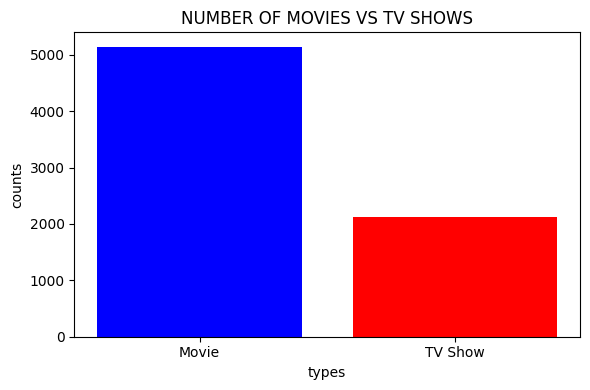

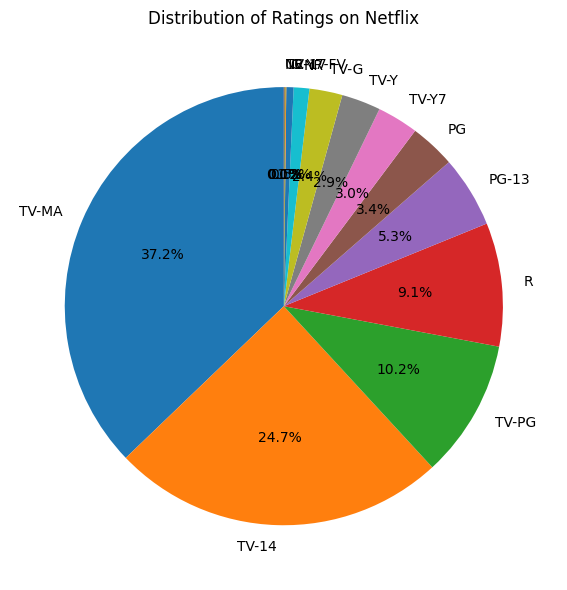

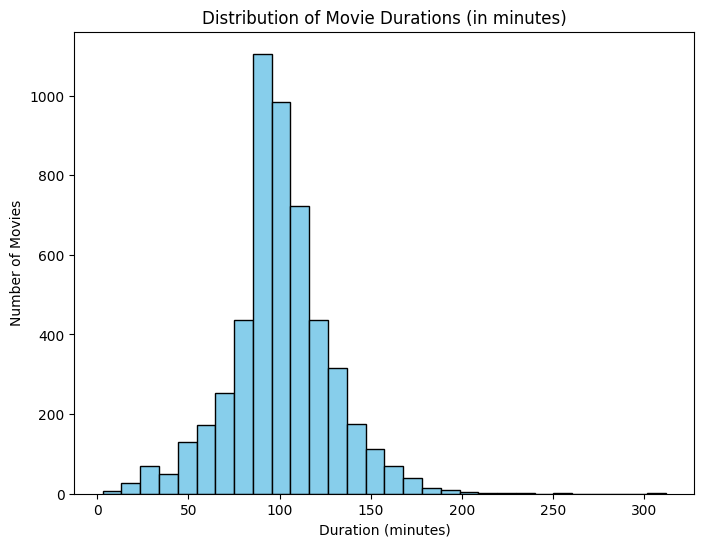

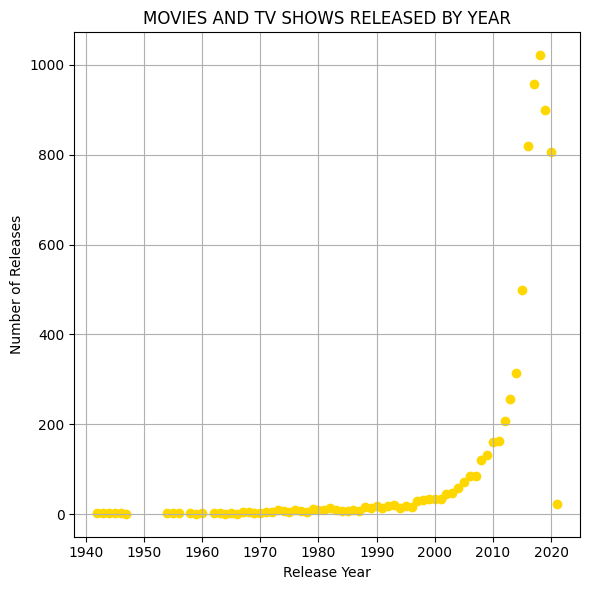

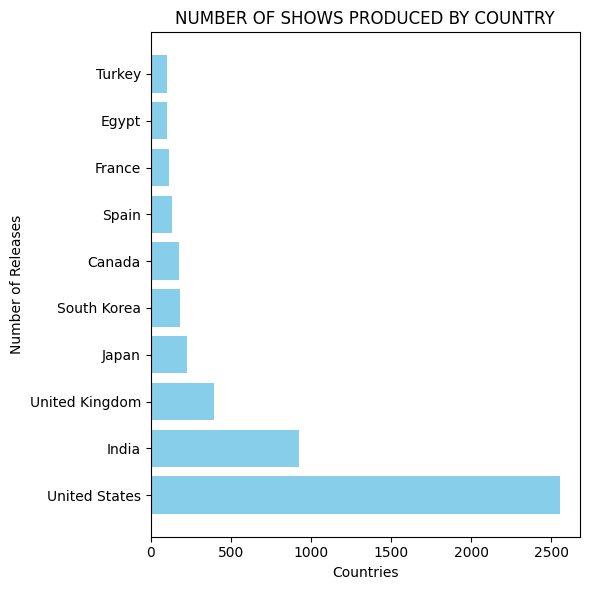

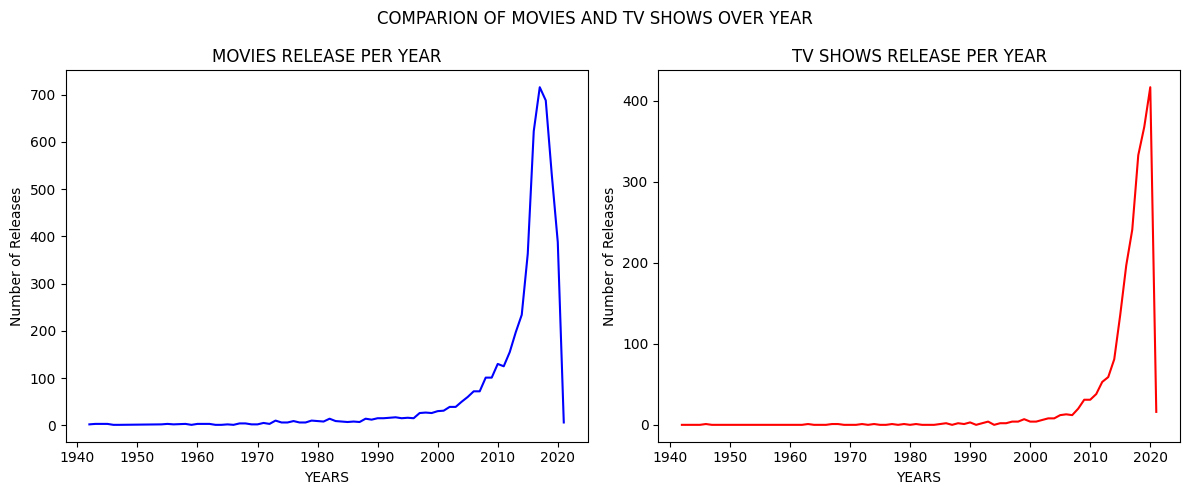

In [1]:
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import os 

# create images folder if not exists
os.makedirs("images", exist_ok=True)

#loading the data 
df = pd.read_csv(r"D:\projects\Netflix-Content-Analysis\dataset\netflix_titles.csv")

#cleaning data
print(df.isnull().sum())
print(df.info())
df =df.dropna(subset = ['type','release_year','rating','country','duration'])

#creating a bar graphy for camparing number of movies and tv shows
type_count = df['type'].value_counts()
plt.figure(figsize = (6,4))
plt.bar(type_count.index,type_count.values,color = ['blue','red'])
plt.title("number of movies vs tv shows".upper())
plt.xlabel("types")
plt.ylabel("counts")
plt.tight_layout()
plt.savefig("images/movies_vs_tvshows.png")
plt.show()

# Distribution of Ratings on Netflix
rating_count = df['rating'].value_counts()
plt.figure(figsize = (6,6))
plt.pie(rating_count.values,labels= rating_count.index,autopct = "%1.1f%%",startangle = 90)
plt.title("Distribution of Ratings on Netflix")
plt.tight_layout()
plt.savefig("images/rating_distribution.png")
plt.show()

# Filter only movies
movie_df = df[df['type'].str.lower() == 'movie'].copy()

# Extract only numbers from duration
movie_df['duration_int'] = movie_df['duration'].str.extract('(\d+)') 
movie_df['duration_int'] = pd.to_numeric(movie_df['duration_int'], errors='coerce')  
movie_df = movie_df.dropna(subset=['duration_int']) 

# Distribution of Movie Durations (in minutes)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Movie Durations (in minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.savefig("images/movie_duration_distribution.png")
plt.show()

# movies_tvshows_released_per_year
release_count = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.scatter(release_count.index ,release_count.values ,color = "gold")
plt.title("Movies and TV Shows Released by Year".upper())
plt.xlabel("Release Year")
plt.ylabel("Number of Releases")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/releases_per_year.png")
plt.show()

#Number of Shows Produced by Country
country_counts = df['country'].value_counts().head(10)
plt.figure(figsize = (6,6))
plt.barh(country_counts.index,country_counts.values,color = "skyblue")
plt.title("Number of Shows Produced by Country".upper())
plt.xlabel("Countries")
plt.ylabel("Number of Releases")
plt.tight_layout()
plt.savefig("images/top_countries.png")
plt.show()

#comparion of movies and tv shows over year
content_by_year = df.groupby(["release_year","type"]).size().unstack().fillna(0)
fig,ax = plt.subplots(1,2, figsize = (12,5))

#first sub_plot is for movies 
ax[0].plot(content_by_year.index , content_by_year["Movie"],color = "blue")
ax[0].set_title("movies release per year".upper())
ax[0].set_xlabel("years".upper())
ax[0].set_ylabel("Number of Releases")

# second sub-plot for tv shows
ax[1].plot(content_by_year.index , content_by_year["TV Show"],color = "red")
ax[1].set_title("tv shows release per year".upper())
ax[1].set_xlabel("years".upper())
ax[1].set_ylabel("Number of Releases")

fig.suptitle("comparion of movies and tv shows over year".upper())
plt.tight_layout()
plt.savefig("images/movies_vs_tvshows_over_year.png")
plt.show()